<a href="https://colab.research.google.com/github/jeisteve999/Analyzing-Africa-Electricty-Access/blob/main/Analyzing_Africa_Electricty_Access.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Electricity Access in Africa (World Bank WDI, 1990–2024)
---



## 1. Data Loading and Initial Exploration

In [1]:
import pandas as pd
import numpy as np


In [2]:
import os
print(os.path.getsize('/content/WDICSV.csv') / (1024*1024), "MB")

189.28688621520996 MB


In [3]:
import os
print(os.path.getsize('/content/WDICSV.csv') / (1024*1024), "MB")

189.28688621520996 MB


In [4]:
import csv

df1 = pd.read_csv('/content/WDICSV.csv', sep=',', engine= 'c', on_bad_lines='skip')
print(df1.shape)

(396970, 70)


In [5]:
df1.shape

(396970, 70)

In [6]:
df1.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,50.667516,52.598171,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.998179,35.240236,36.080572,NaN


In [7]:
df1['Country Name'].nunique()

265

In [8]:
df1["Indicator Name"].nunique()

1498

In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396970 entries, 0 to 396969
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    396970 non-null  object 
 1   Country Code    396970 non-null  object 
 2   Indicator Name  396970 non-null  object 
 3   Indicator Code  396970 non-null  object 
 4   1960            37226 non-null   float64
 5   1961            42560 non-null   float64
 6   1962            43847 non-null   float64
 7   1963            44777 non-null   float64
 8   1964            45283 non-null   float64
 9   1965            47096 non-null   float64
 10  1966            47354 non-null   float64
 11  1967            47991 non-null   float64
 12  1968            48608 non-null   float64
 13  1969            49391 non-null   float64
 14  1970            72137 non-null   float64
 15  1971            76468 non-null   float64
 16  1972            78158 non-null   float64
 17  1973      

### Key Findings
- The raw WDI file weighs about 189 MB and contains **396,970 rows × 70 columns**: four identifier columns plus one column per year from 1960 to 2025.
- It includes **265 entities** (countries plus aggregates such as "Arab World" or "Africa Eastern and Southern") and **1,498 different indicators**.
- Data availability improves a lot over time: about 72,000 non-null values in 1970, 129,000 in 1990 and 223,000 in 2010. This is why the analysis starts in **1990**.

## 2. Data Cleaning and Reshaping (Long Format)

In [10]:
print("Duplicates:",df1.duplicated().sum())

Duplicates: 0


In [11]:
id_cols = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
years_col = [str(y) for y in range (1990, 2026)]
df1 = df1[id_cols + years_col]

In [12]:
df1.shape

(396970, 40)

In [13]:
df1.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998',
       '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016',
       '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'],
      dtype='object')

In [14]:
df1[years_col] = df1[years_col].apply(pd.to_numeric, errors = 'coerce')

In [15]:
df_long = df1.melt(id_vars=id_cols, value_vars=years_col, var_name='year',value_name='Value')

In [16]:
df_long

,Country Name,Country Code,Indicator Name,Indicator Code,year,Value
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1990,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1990,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1990,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,1990,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1990,NaN
...,...,...,...,...,...,...
14290915,Zimbabwe,ZWE,Women who believe a husband is justified in be...,SG.VAW.REFU.ZS,2025,NaN
14290916,Zimbabwe,ZWE,Women who were first married by age 15 (% of w...,SP.M15.2024.FE.ZS,2025,NaN
14290917,Zimbabwe,ZWE,Women who were first married by age 18 (% of w...,SP.M18.2024.FE.ZS,2025,NaN
14290918,Zimbabwe,ZWE,Women's share of population ages 15+ living wi...,SH.DYN.AIDS.FE.ZS,2025,NaN


### Key Findings
- There were **no duplicated rows** in the raw data.
- After keeping 1990–2025 and reshaping to long format, the dataset has **14,290,920 rows** (396,970 series × 36 years), with one row per country, indicator and year.

## 3. Enriching the Data with Country Metadata (Region and Income Group)

In [17]:
df_country= pd.read_csv('/content/WDICountry.csv', sep = ',', engine= 'c', low_memory =False)

df_country.columns.tolist()

['Country Code',
 'Short Name',
 'Table Name',
 'Long Name',
 '2-alpha code',
 'Currency Unit',
 'Special Notes',
 'Region',
 'Income Group',
 'WB-2 code',
 'National accounts base year',
 'National accounts reference year',
 'SNA price valuation',
 'Lending category',
 'Other groups',
 'System of National Accounts',
 'Alternative conversion factor',
 'PPP survey year',
 'Balance of Payments Manual in use',
 'External debt Reporting status',
 'System of trade',
 'Government Accounting concept',
 'IMF data dissemination standard',
 'Latest population census',
 'Latest household survey',
 'Source of most recent Income and expenditure data',
 'Vital registration complete',
 'Latest agricultural census',
 'Latest industrial data',
 'Latest trade data',
 'Latest water withdrawal data']

In [18]:
df_country["Region"].unique()

array(['Latin America & Caribbean', nan, 'Middle East & North Africa',
       'Sub-Saharan Africa', 'Europe & Central Asia',
       'East Asia & Pacific', 'South Asia', 'North America'], dtype=object)

In [19]:
df_country.slim = df_country[['Country Code', 'Short Name','Region', 'Income Group']]

/tmp/ipykernel_67179/2288855474.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_country.slim = df_country[['Country Code', 'Short Name','Region', 'Income Group']]


In [20]:
df_long = df_long.merge(df_country.slim, on = 'Country Code', how= 'left')

### Key Findings
- Adding `Region` and `Income Group` lets us filter by geography and compare countries by income level.
- Aggregates such as "Arab World" have no region (NaN), so they are naturally excluded when we filter African countries.

## 4. Filtering African Countries (Sub-Saharan Africa + North Africa)

In [21]:
norte_africa_codes = ['DZA', 'EGY', 'LBY', 'MAR', 'TUN', 'SDN']

In [22]:
df_africa = df_long.loc[
    (df_long['Region'] == 'Sub-Saharan Africa') |
    ((df_long['Region'] == 'Middle East & North Africa') & (df_long['Country Code'].isin(norte_africa_codes)))
]

In [23]:
df_africa

,Country Name,Country Code,Indicator Name,Indicator Code,year,Value,Short Name,Region,Income Group
74900,Algeria,DZA,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1990,NaN,Algeria,Middle East & North Africa,Upper middle income
74901,Algeria,DZA,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1990,NaN,Algeria,Middle East & North Africa,Upper middle income
74902,Algeria,DZA,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1990,NaN,Algeria,Middle East & North Africa,Upper middle income
74903,Algeria,DZA,Access to electricity (% of population),EG.ELC.ACCS.ZS,1990,NaN,Algeria,Middle East & North Africa,Upper middle income
74904,Algeria,DZA,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1990,NaN,Algeria,Middle East & North Africa,Upper middle income
...,...,...,...,...,...,...,...,...,...
14290915,Zimbabwe,ZWE,Women who believe a husband is justified in be...,SG.VAW.REFU.ZS,2025,NaN,Zimbabwe,Sub-Saharan Africa,Lower middle income
14290916,Zimbabwe,ZWE,Women who were first married by age 15 (% of w...,SP.M15.2024.FE.ZS,2025,NaN,Zimbabwe,Sub-Saharan Africa,Lower middle income
14290917,Zimbabwe,ZWE,Women who were first married by age 18 (% of w...,SP.M18.2024.FE.ZS,2025,NaN,Zimbabwe,Sub-Saharan Africa,Lower middle income
14290918,Zimbabwe,ZWE,Women's share of population ages 15+ living wi...,SH.DYN.AIDS.FE.ZS,2025,NaN,Zimbabwe,Sub-Saharan Africa,Lower middle income


In [24]:
print("Unique Countries:", df_africa["Country Code"].nunique())

Unique Countries: 53


In [25]:
africa_countries = df_africa[['Country Name', 'Country Code', 'Region']].drop_duplicates().sort_values('Country Name')
africa_countries

,Country Name,Country Code,Region
74900,Algeria,DZA,Middle East & North Africa
79394,Angola,AGO,Sub-Saharan Africa
101864,Benin,BEN,Sub-Saharan Africa
109354,Botswana,BWA,Sub-Saharan Africa
116844,Burkina Faso,BFA,Sub-Saharan Africa
118342,Burundi,BDI,Sub-Saharan Africa
119840,Cabo Verde,CPV,Sub-Saharan Africa
122836,Cameroon,CMR,Sub-Saharan Africa
127330,Central African Republic,CAF,Sub-Saharan Africa
128828,Chad,TCD,Sub-Saharan Africa


In [26]:
print("Shape de df_africa:", df_africa.shape)

Shape de df_africa: (2858184, 9)


In [27]:
df_country[df_country['Country Code'] == 'DJI'][['Country Code', 'Short Name', 'Region']]

,Country Code,Short Name,Region
56,DJI,Djibouti,Middle East & North Africa


In [28]:
df_long[df_long['Country Code']== 'DJI'][['Country Name', 'Country Code', ]].drop_duplicates()

,Country Name,Country Code
152796,Djibouti,DJI


In [29]:
norte_africa_codes = ['DZA', 'EGY', 'LBY', 'MAR', 'TUN', 'SDN', 'DJI']

In [30]:
df_africa = df_long.loc[
    (df_long['Region'] == 'Sub-Saharan Africa') |
    ((df_long['Region'] == 'Middle East & North Africa') & (df_long['Country Code'].isin(norte_africa_codes)))
]

In [31]:
print("Unique Countries:", df_africa['Country Code'].nunique())
print("Shape de df_africa:", df_africa.shape)

Unique Countries: 54
Shape de df_africa: (2912112, 9)


### Key Findings
- The World Bank places most North African countries in "Middle East & North Africa", so they were added manually using their country codes.
- The first filter returned **53 countries**. Djibouti was missing because it is classified under MENA, so it was added too.
- The final African dataset has **54 countries** and **2,912,112 rows**.

## 5. Missing Values and Indicator Coverage

In [32]:
total_files = len(df_africa)

In [33]:
nulls_value= df_africa["Value"].isna().sum()

In [34]:
df_africa_clean= df_africa.dropna(subset=['Value'].copy())

In [35]:
print("shape before:", df_africa.shape)
print("shape after", df_africa_clean.shape)

shape before: (2912112, 9)
shape after (1505042, 9)


In [36]:
dup_check = df_africa_clean.duplicated(subset= ['Country Code', 'Indicator Code','year']).sum()
print("Country-indicator-year duplicates:", dup_check)

Country-indicator-year duplicates: 0


In [37]:
cobertura = df_africa_clean.groupby('Indicator Name')['Value'].count().sort_values(ascending= False)
cobertura.head(20)

,Value
Indicator Name,
"Age dependency ratio, young (% of working-age population)",1944
Population ages 0-14 (% of total population),1944
Net migration,1944
Rural population (% of total population),1944
"Age dependency ratio, old (% of working-age population)",1944
Age dependency ratio (% of working-age population),1944
"Population ages 15-64, female (% of female population)",1944
"Population ages 25-29, male (% of male population)",1944
"Population ages 15-64, female",1944


### Key Findings
- Of 2,912,112 rows, **1,407,070 (about 48%) had no value** and were removed, leaving **1,505,042 rows**.
- After cleaning, there are no duplicated country-indicator-year combinations.
- The best-covered indicators have **1,944 observations**, which equals 54 countries × 36 years. They are demographic indicators (population by age and sex, rural population, net migration) and have complete coverage.

## 6. Selecting the Electricity Access Indicator

In [38]:
df_africa_clean[df_africa_clean['Indicator Name'].str.contains('Access to electricity', case=False, na=False)]['Indicator Name'].unique()

array(['Access to electricity (% of population)',
       'Access to electricity, rural (% of rural population)',
       'Access to electricity, urban (% of urban population)'],
      dtype=object)

In [39]:
df_electricity = df_africa_clean[
    df_africa_clean['Indicator Name'] == 'Access to electricity (% of population)'
]
print("Shape df_electricity", df_electricity.shape)

Shape df_electricity (1561, 9)


In [40]:
pivot_electricity = df_electricity.pivot_table(
    index = 'Country Name',
    columns = 'year',
    values = 'Value',
    aggfunc='mean'
)
pivot_electricity.head()

year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Country Name,,,,,,,,,,,,,,,,,,,,,
Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,99.4,99.4,99.5,99.6,99.5,99.7,99.8,100.0,100.0,100.0
Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,42.0,41.8,42.9,45.3,45.6,47.0,48.2,48.5,51.1,55.5
Benin,NaN,NaN,NaN,NaN,NaN,NaN,14.500000,18.589626,19.578255,20.562042,...,29.6,37.0,34.5,39.0,40.0,41.0,42.0,56.5,57.0,59.0
Botswana,NaN,10.1,9.398227,11.642076,13.884566,16.125017,18.362747,20.597078,22.827330,25.052740,...,62.1,64.2,67.4,68.3,70.1,71.8,73.7,75.9,76.0,80.2
Burkina Faso,NaN,NaN,NaN,6.100000,6.125010,6.625333,7.122936,7.617140,8.107265,6.900000,...,16.2,16.6,17.0,14.4,17.6,18.5,19.0,19.5,21.7,34.0


### Key Findings
- Three electricity indicators exist: total, rural and urban access. We focus on **total access (% of population)**.
- It has **1,561 observations out of 1,890 possible** (54 countries × 35 years), so about 83% of country-years have data.
- Early years have many gaps. For example, Algeria and Angola have no values in the 1990s.

In [41]:
print(df1.shape)
df1['Country Name'].unique()[:10]

(396970, 40)


array(['Africa Eastern and Southern', 'Africa Western and Central',
       'Arab World', 'Caribbean small states',
       'Central Europe and the Baltics', 'Early-demographic dividend',
       'East Asia & Pacific',
       'East Asia & Pacific (excluding high income)',
       'East Asia & Pacific (IDA & IBRD countries)', 'Euro area'],
      dtype=object)

In [42]:
[c for c in df_africa_clean['Indicator Name'].unique() if 'lectricity' in c][:5]

['Electricity production from coal sources (% of total)',
 'Electricity production from hydroelectric sources (% of total)',
 'Electricity production from natural gas sources (% of total)',
 'Electricity production from nuclear sources (% of total)',
 'Electricity production from oil sources (% of total)']

In [43]:
pivot_electricity.loc["Nigeria"]

,Nigeria
year,
1990,27.300000
1991,35.234600
1992,36.099461
1993,36.963646
1994,37.826469
1995,38.687252
1996,39.545319
1997,40.399982
1998,41.250568


## 7. Country Classification by Electricity Access Level (2024)

In [44]:
import numpy as np

In [45]:
last_year = pivot_electricity.columns.max()
first_year = pivot_electricity.columns.min()

In [46]:
print(last_year)
print(first_year)

2024
1990


In [47]:
conditions = [
    pivot_electricity[last_year] >= 80,
    pivot_electricity[last_year] >= 40
]

categories = ["High Access", "Medium Access"]
pivot_electricity["Level_2024"] = np.select(conditions, categories, default = 'Low access')


In [48]:
pivot_electricity["growth"] = pivot_electricity[last_year] - pivot_electricity[first_year]

In [49]:
idx_best = np.nanargmax(pivot_electricity["growth"].values)

print("Country with the greatest improvement in access to electricity:", pivot_electricity.index[idx_best])

Country with the greatest improvement in access to electricity: Zambia


### Key Findings
- Countries were classified by their 2024 access level: **High (≥ 80%)**, **Medium (≥ 40%)** and **Low (< 40%)**.
- A first attempt measured improvement as the change in percentage points between 1990 and 2024. However, only 4 countries have data for 1990, so that ranking is not representative (it pointed to Zambia only because most countries were excluded).
- For a reliable comparison, improvement is measured from **2000 to 2024** in Section 13, where 51 countries have valid data.

## 8. Indicator Metadata (WDISeries)

In [50]:
df_series = pd.read_csv('/content/WDISeries.csv', sep= ',', engine = 'c', low_memory= False)

print(df_series.columns.tolist())

['Series Code', 'Topic', 'Indicator Name', 'Short definition', 'Long definition', 'Unit of measure', 'Periodicity', 'Base Period', 'Other notes', 'Aggregation method', 'Limitations and exceptions', 'Notes from original source', 'General comments', 'Source', 'Statistical concept and methodology', 'Development relevance', 'Related source links', 'Other web links', 'Related indicators', 'License Type']


In [51]:
df_series_slim =  df_series[['Series Code', 'Topic', 'Short definition']]

df_long = df_long.merge(
    df_series_slim,
    left_on= 'Indicator Code',
    right_on = 'Series Code',
    how='left'
)

df_long

,Country Name,Country Code,Indicator Name,Indicator Code,year,Value,Short Name,Region,Income Group,Series Code,Topic,Short definition
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1990,NaN,Africa Eastern and Southern,NaN,NaN,EG.CFT.ACCS.ZS,Environment: Energy production & use,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1990,NaN,Africa Eastern and Southern,NaN,NaN,EG.CFT.ACCS.RU.ZS,Environment: Energy production & use,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1990,NaN,Africa Eastern and Southern,NaN,NaN,EG.CFT.ACCS.UR.ZS,Environment: Energy production & use,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,1990,NaN,Africa Eastern and Southern,NaN,NaN,EG.ELC.ACCS.ZS,Environment: Energy production & use,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1990,NaN,Africa Eastern and Southern,NaN,NaN,EG.ELC.ACCS.RU.ZS,Environment: Energy production & use,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
14290915,Zimbabwe,ZWE,Women who believe a husband is justified in be...,SG.VAW.REFU.ZS,2025,NaN,Zimbabwe,Sub-Saharan Africa,Lower middle income,SG.VAW.REFU.ZS,Gender: Health,NaN
14290916,Zimbabwe,ZWE,Women who were first married by age 15 (% of w...,SP.M15.2024.FE.ZS,2025,NaN,Zimbabwe,Sub-Saharan Africa,Lower middle income,SP.M15.2024.FE.ZS,Gender: Agency,NaN
14290917,Zimbabwe,ZWE,Women who were first married by age 18 (% of w...,SP.M18.2024.FE.ZS,2025,NaN,Zimbabwe,Sub-Saharan Africa,Lower middle income,SP.M18.2024.FE.ZS,Gender: Agency,NaN
14290918,Zimbabwe,ZWE,Women's share of population ages 15+ living wi...,SH.DYN.AIDS.FE.ZS,2025,NaN,Zimbabwe,Sub-Saharan Africa,Lower middle income,SH.DYN.AIDS.FE.ZS,Health: Risk factors,NaN


In [52]:
years = [c for c in pivot_electricity.columns if isinstance(c,(int, np.integer))]

pivot_electricity[years] = (
    pivot_electricity[years]
    .interpolate(axis = 1, limit_direction = "both")
)

years

[]

## 9. Highest vs. Lowest Electricity Access in 2024

In [53]:
top5 = pivot_electricity[[last_year]].sort_values(by = last_year, ascending= False).head(5)
top5["group"] = "Highest access"

bottom5 = pivot_electricity[[last_year]].sort_values(by= last_year, ascending = False).tail(5)
bottom5["group"] = "Lowest access"

comparison = pd.concat([top5, bottom5])
print(comparison)

year                       2024           group
Country Name                                   
Algeria                   100.0  Highest access
Egypt, Arab Rep.          100.0  Highest access
Seychelles                100.0  Highest access
Tunisia                   100.0  Highest access
Mauritius                 100.0  Highest access
Burundi                    20.1   Lowest access
Central African Republic   18.2   Lowest access
Malawi                     15.6   Lowest access
Chad                       13.4   Lowest access
South Sudan                 5.4   Lowest access


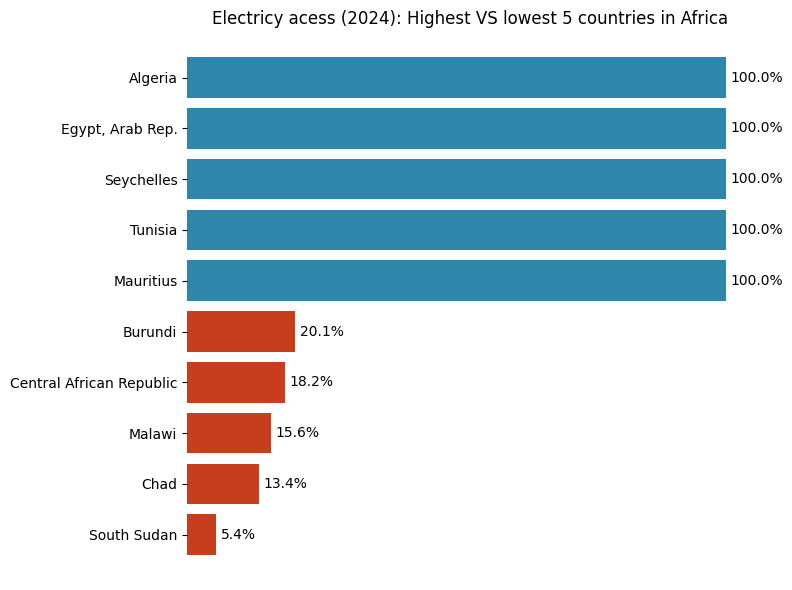

In [54]:
#Electricity Access in Africa
import pandas as pd
import matplotlib.pyplot as plt

colors = ["#2E86AB" if g == "Highest access" else "#C73E1D" for g in comparison["group"]]

fig, ax = plt.subplots(figsize = (8, 6))
bars = ax.barh(comparison.index, comparison[last_year], color = colors)

ax.set_title(f"Electricy acess ({last_year}): Highest VS lowest 5 countries in Africa")
ax.set_label("% of population with access to electricity")
ax.set_xticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.bar_label(bars, fmt="%.1f%%", padding= 3)

ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Key Findings
- Five countries (Algeria, Egypt, Seychelles, Tunisia and Mauritius) reach **100% access** in 2024.
- The five lowest are **Burundi (20.1%), Central African Republic (18.2%), Malawi (15.6%), Chad (13.4%) and South Sudan (5.4%)**.
- The gap between both groups is about **95 percentage points**, which shows how unequal electricity access is across the continent.
- Several countries tie at 100%, so the "top 5" is not a strict ranking.


## 10. Exploratory Analysis of Indicator Names (Text Analysis)

In [55]:
import re

unique_indicators = df_africa_clean['Indicator Name'].drop_duplicates()

clean_indicators = unique_indicators.str.replace(r'\(.*?\)', '', regex=True)
clean_indicators = clean_indicators.str.replace(r'[^\w\s]', ' ', regex=True)
clean_indicators = clean_indicators.str.strip().str.lower()


In [56]:
tokens = clean_indicators.str.split()
tokens.head()

,Indicator Name
74919,"[adjusted, net, enrollment, rate, primary]"
74920,"[adjusted, net, enrollment, rate, primary, fem..."
74921,"[adjusted, net, enrollment, rate, primary, male]"
74922,"[adjusted, net, national, income]"
74923,"[adjusted, net, national, income]"


In [57]:
all_words = tokens.explode()
world_counts = all_words.value_counts()
world_counts.head()

,count
Indicator Name,
of,272
and,178
net,144
in,143
female,140


In [58]:
stopwords = ['of', 'and', 'in', 'the', 'to', 'for', 'a', 'on', 'at', 'with', 'from', 'per']

meaningful_words = all_words[~all_words.isin(stopwords)]
word_counts_clean = meaningful_words.value_counts()
word_counts_clean.head(20)

,count
Indicator Name,
net,144
female,140
male,133
population,127
services,92
total,89
ages,86
rate,86
expenditure,77


### Key Findings
- The most frequent words in indicator names are "net", "female", "male" and "population", followed by "services", "education", "primary" and "employment".
- This shows that the WDI catalog is dominated by **demographic indicators** (by sex and age), **education** and **economic flows**.
- Electricity access is only a small part of a much larger catalog.

## 11. Electricity Access Over Time: Selected African Countries

In [59]:
year_columns = [c for c in pivot_electricity.columns if isinstance( c, (int, np.integer))]
print(year_columns[:5], "...Total:", len(year_columns))

[] ...Total: 0


In [60]:
print("pivot_electricity shape:", pivot_electricity.shape)
print("year_columns:", year_columns[:5], "... total:", len(year_columns))
print(pivot_electricity.reset_index().shape)

pivot_electricity shape: (54, 37)
year_columns: [] ... total: 0
(54, 38)


In [61]:
pivot_electricity.columns = [int(c) if str(c).isdigit() else c for c in pivot_electricity.columns]

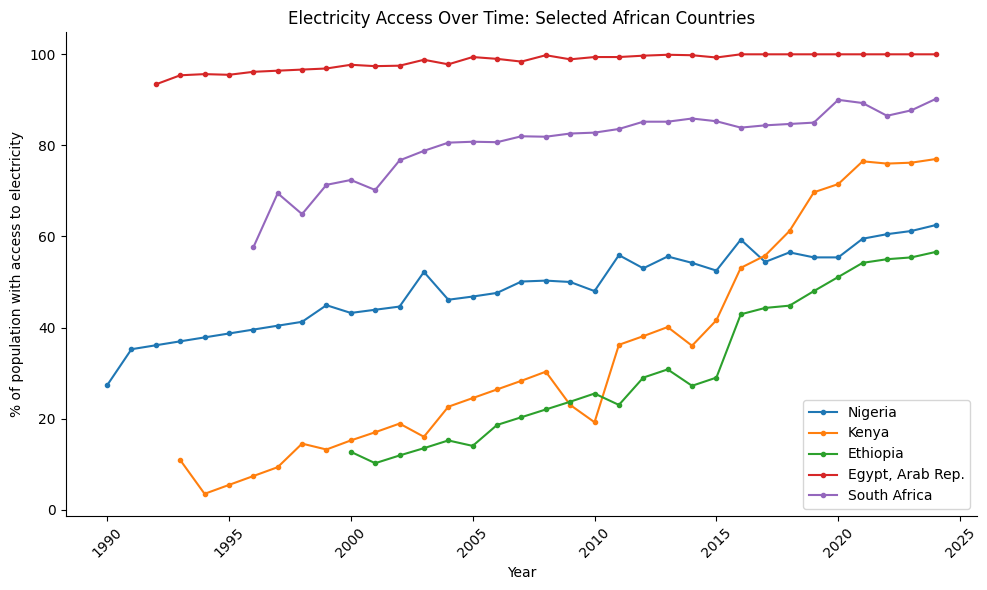

In [86]:
countries_to_plot = ['Nigeria', 'Kenya', 'Ethiopia', 'Egypt, Arab Rep.', 'South Africa']

fig, ax= plt.subplots(figsize=(10,6))

for country in countries_to_plot:
      ax.plot(year_columns, pivot_electricity.loc[country, year_columns], label=country, marker='o', markersize=3)


ax.set_title('Electricity Access Over Time: Selected African Countries')
ax.set_xlabel('Year')
ax.set_ylabel('% of population with access to electricity')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Key Findings
- **Egypt** has had near-universal access since the early 1990s and stays at about 100% from 2016.
- **South Africa** rose from about 58% in 1996 to around 90% in 2020, then dipped slightly to about 87%.
- **Nigeria** grew slowly and steadily, from about 27% in 1990 to about 61% in 2023.
- **Kenya** had the fastest recent growth, from about 19% in 2010 to about 76% in 2023, and overtook Nigeria around 2017.
- **Ethiopia** also grew quickly after 2015, reaching about 55% in 2023.

In [63]:
codes_to_plot = ['NGA', 'KEN', 'ETH', 'EGY', 'ZAF']
code_to_name = df_africa_clean[['Country Code', 'Country Name']].drop_duplicates().set_index('Country Code')['Country Name']
countries_to_plot = [code_to_name[code] for code in codes_to_plot]
print(countries_to_plot)

['Nigeria', 'Kenya', 'Ethiopia', 'Egypt, Arab Rep.', 'South Africa']


In [64]:
pivot_electricity.columns[:5]

Index([1990, 1991, 1992, 1993, 1994], dtype='object')

In [65]:
year_columns = [c for c in pivot_electricity.columns if isinstance( c, (int, np.integer))]
print(year_columns[:5], "...Total:", len(year_columns))

[1990, 1991, 1992, 1993, 1994] ...Total: 35


In [66]:
df_plot = pivot_electricity.reset_index()[['Country Name'] + year_columns].melt(
    id_vars='Country Name', var_name='year', value_name='Access'
)

df_plot_selected = df_plot[df_plot['Country Name'].isin(countries_to_plot)]

print(df_plot.shape)
print(df_plot_selected.shape)

(1890, 3)
(175, 3)


In [67]:
import plotly.express as px
fig = px.line(
    df_plot_selected,
    x='year', y='Access', color='Country Name',
    title='Electricity Access Over Time: Selected African Countries',
    markers=True
)

fig.update_traces(hovertemplate='<b>%{fulldata.name}<\b><b>Year:%{x}<br>Access:%{y:2f}%<extra></extra>')

fig.show()

## 12. Distribution of Electricity Access in 2024

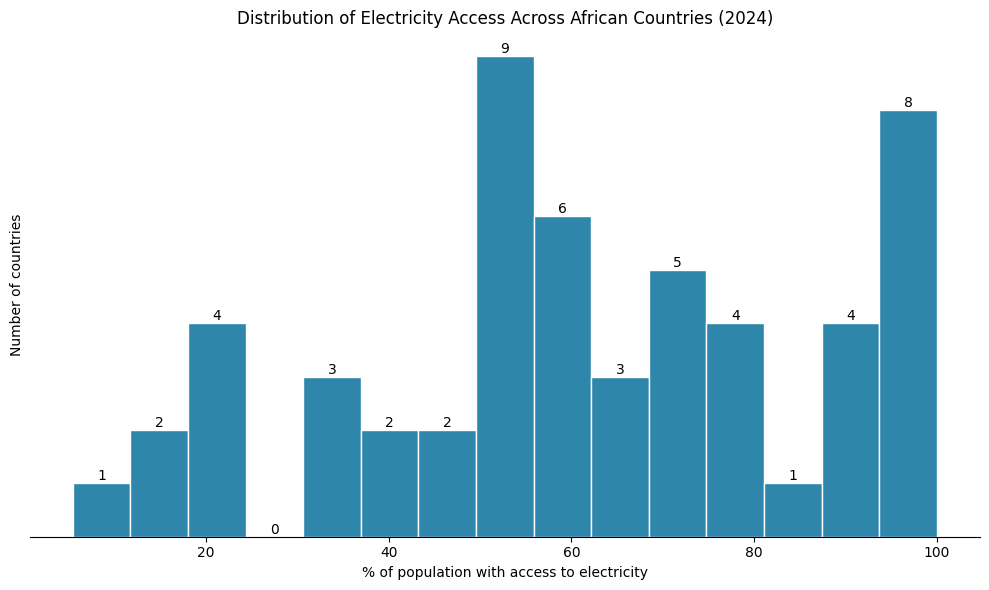

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches = ax.hist(pivot_electricity[2024].dropna(), bins=15, color='#2E86AB', edgecolor='white')

ax.bar_label(patches, fmt='%.0f')

ax.set_title('Distribution of Electricity Access Across African Countries (2024)')
ax.set_xlabel('% of population with access to electricity')
ax.set_ylabel('Number of countries')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticks([])

plt.tight_layout()
plt.show()

### Key Findings
- The distribution is **not concentrated around one value**: 8 countries are close to 100%, while another large group sits around 50–55%.
- Several countries remain below 25%, so a long tail of low-access countries persists.

In [69]:
print("Countries with valid Growth:", pivot_electricity['growth'].notna().sum())
print("Countries with valid NaN:", pivot_electricity['growth'].isna().sum())

Countries with valid Growth: 4
Countries with valid NaN: 50


In [70]:
pivot_electricity[year_columns].notna().sum().sort_values()

,0
1990,4
1991,7
1992,15
1993,19
1994,23
1995,25
1996,30
1997,33
1998,35
1999,36


In [71]:
pivot_electricity['growth'] = pivot_electricity[2024] - pivot_electricity[2000]
print('Countries with valid growth:', pivot_electricity['growth'].notna().sum())

Countries with valid growth: 51


## 13. Growth in Access vs. Current Access (2000–2024)

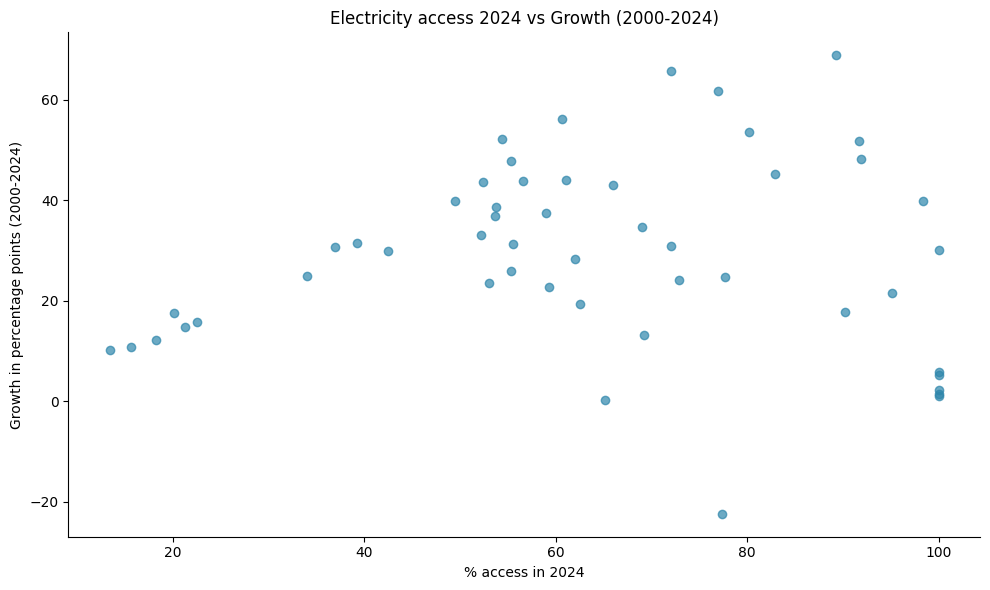

In [72]:
fig, ax = plt.subplots(figsize =(10,6))

ax.scatter(pivot_electricity[2024], pivot_electricity['growth'], color='#2E86AB', alpha = 0.7)

ax.set_title('Electricity access 2024 vs Growth (2000-2024)')
ax.set_xlabel('% access in 2024')
ax.set_ylabel('Growth in percentage points (2000-2024)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Key Findings
- Countries were classified by their 2024 access level: **High (≥ 80%)**, **Medium (≥ 40%)** and **Low (< 40%)**.
- Only 4 countries have data for 1990, so improvement was measured from **2000 to 2024**, when 51 countries have valid data.
- **Eswatini** shows the largest gain (from 20.4% to 89.3%, +68.9 percentage points).
- **Libya** is the only country with a large decline (from 99.8% to 77.4%, −22.4 points).
- Guinea-Bissau, Liberia and South Sudan have no 2000 value, so their growth cannot be computed.

In [73]:
print('Highest growth')
print(pivot_electricity[[2000, 2024, 'growth']].sort_values('growth', ascending=False).head(1))

print("\nLargest Decline:")
print(pivot_electricity[[2000, 2024, 'growth']].sort_values('growth', ascending=True).head(1))

Highest growth
              2000  2024  growth
Country Name                    
Eswatini      20.4  89.3    68.9

Largest Decline:
              2000  2024  growth
Country Name                    
Libya         99.8  77.4   -22.4


In [74]:
df_electricity[['Country Name', 'Income Group', 'Value']].head()

,Country Name,Income Group,Value
260655,Mauritius,Upper middle income,99.041565
287619,Nigeria,Lower middle income,27.300000
349037,Sudan,Low income,32.800000
393977,Zambia,Lower middle income,13.900000
506327,Botswana,Upper middle income,10.100000


## 14. Electricity Access by Income Group

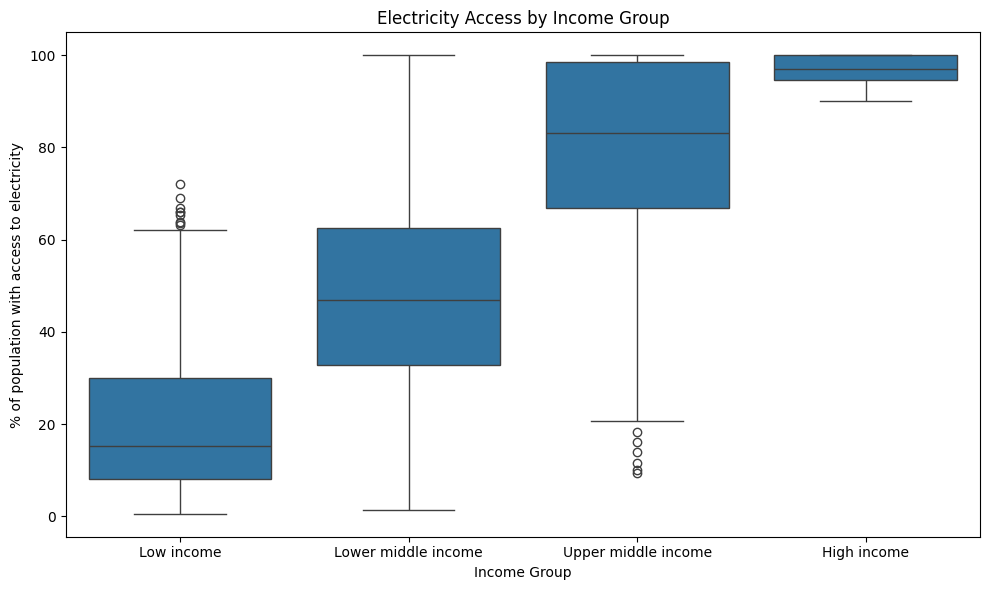

In [75]:
import seaborn as sns

fig, ax = plt.subplots(figsize= (10,6))

income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']

sns.boxplot(data=df_electricity, x='Income Group', y='Value', order=income_order, ax=ax)

ax.set_title('Electricity Access by Income Group')
ax.set_xlabel('Income Group')
ax.set_ylabel('% of population with access to electricity')

plt.tight_layout()
plt.show()

### Key Findings
- Access rises clearly with income level: the median is about 15% for low income, about 47% for lower middle, about 83% for upper middle and close to 100% for high income.
- Lower middle and upper middle income groups show the widest ranges, so income alone does not guarantee access.
- The boxplot pools all years (1990–2024), so it reflects the whole period, not only 2024.

## 15. Electricity Access Levels Across Africa (2024)

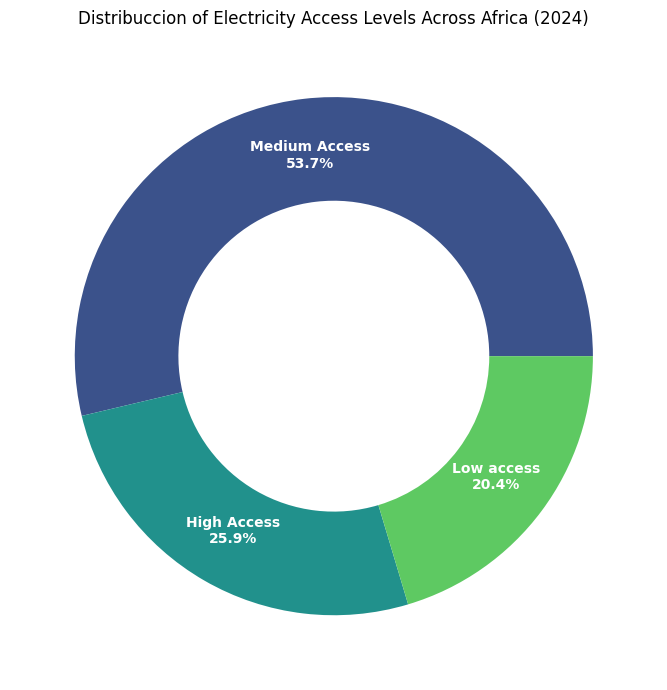

In [76]:
level_counts = pivot_electricity['Level_2024'].value_counts()


labels_combined = [f"{name}\n{count/level_counts.sum()*100:.1f}%" for name, count in level_counts.items()]

fig, ax = plt.subplots(figsize = (7, 7))

wedges, texts = ax.pie(
    level_counts,
    labels=labels_combined,
    colors= sns.color_palette('viridis', len(level_counts)),
    wedgeprops=dict(width=0.4),
    labeldistance = 0.78,
)

plt.setp(texts, color= 'white', weight='bold', ha='center')

ax.set_title('Distribuccion of Electricity Access Levels Across Africa (2024)')

plt.tight_layout()
plt.show()


### Key Findings
- About **54%** of countries have medium access, **26%** high access and **20%** low access.
- Only about a quarter of African countries reach 80% or more.

In [77]:
nombre_real = [i for i in df_africa_clean['Indicator Name'].unique() if 'lectricity' in i and 'population' in i][0]

print(repr(nombre_real))
print(len(nombre_real))

nombre_comparacion = 'Access to electricity (% of population)'
print(repr(nombre_comparacion))
print(len(nombre_comparacion))

print(nombre_real == nombre_comparacion)

'Access to electricity (% of population)'
39
'Access to electricity (% of population)'
39
True


In [78]:
df_plot_africa = df_africa_clean[df_africa_clean['Indicator Name'] == 'Access to electricity (% of population)']

In [79]:
[i for i in df_africa_clean['Indicator Name'].unique() if 'lectricity' in i and 'population' in i]

['Access to electricity (% of population)',
 'Access to electricity, rural (% of rural population)',
 'Access to electricity, urban (% of urban population)']

In [80]:
df_plot_africa = df_africa_clean[df_africa_clean['Indicator Name']=='Access to electricity (%of population)']

fig, px.bar(
    df_plot_africa.sort_values('year'),
    x='Value', y='Country Name',
    animation_frame='year',
    orientation='h',
    range_x=[0,100],
    title='Electricity Acess Evolution By Country'
)

fig.show()

In [81]:
df_plot_africa = df_africa_clean[df_africa_clean['Indicator Name']==nombre_real]

print(df_plot_africa.shape)
df_plot_africa.head()

(1561, 9)


,Country Name,Country Code,Indicator Name,Indicator Code,year,Value,Short Name,Region,Income Group
260655,Mauritius,MUS,Access to electricity (% of population),EG.ELC.ACCS.ZS,1990,99.041565,Mauritius,Sub-Saharan Africa,Upper middle income
287619,Nigeria,NGA,Access to electricity (% of population),EG.ELC.ACCS.ZS,1990,27.300000,Nigeria,Sub-Saharan Africa,Lower middle income
349037,Sudan,SDN,Access to electricity (% of population),EG.ELC.ACCS.ZS,1990,32.800000,Sudan,Sub-Saharan Africa,Low income
393977,Zambia,ZMB,Access to electricity (% of population),EG.ELC.ACCS.ZS,1990,13.900000,Zambia,Sub-Saharan Africa,Lower middle income
506327,Botswana,BWA,Access to electricity (% of population),EG.ELC.ACCS.ZS,1991,10.100000,Botswana,Sub-Saharan Africa,Upper middle income


## 16. Interactive Animation and HTML Export

In [82]:
fig = px.bar(
    df_plot_africa.sort_values('year'),
    x='Value', y='Country Name',
    animation_frame='year',
    orientation='h',
    range_x=[0,100],
    title='Electricity Access Evolution By Country'
)

fig.show()

In [83]:
fig.write_html('/content/electricity_animation.html')

### Key Findings
- The animation shows how access changes year by year for each country, and was exported as a standalone HTML file (about 4.5 MB) that can be shared without Python.

In [84]:
import os
print(os.path.exists('/content/electricity_animation.html'))
print(os.path.getsize('/content/electricity_animation.html') / 1024, "KB")

True
4507.3740234375 KB


## 17. Styled Summary Table

In [85]:
summary_table = pivot_electricity[[2000, 2024, 'growth']].round(1)

styled_table = (
    summary_table.style
    .format('{:.1f}')
    .background_gradient(subset=[2024], cmap='Greens')
    .highlight_max(subset=['growth'], color='lightgreen')
    .highlight_min(subset=['growth'], color='lightcoral')
)

styled_table

,2000,2024,growth
Country Name,,,
Algeria,98.6,100.0,1.4
Angola,24.2,55.5,31.3
Benin,21.5,59.0,37.5
Botswana,26.5,80.2,53.7
Burkina Faso,9.1,34.0,24.9
Burundi,2.5,20.1,17.6
Cabo Verde,58.6,98.4,39.8
Cameroon,41.0,72.0,31.0
Central African Republic,6.0,18.2,12.2


### Key Findings
- The table combines access in 2000, access in 2024 and growth. Green shading marks higher 2024 access, the highest growth is highlighted in green and the largest decline (Libya) in red.

## Conclusions
- Electricity access in Africa is **highly unequal**: some countries have universal access while others are below 20%.
- Access increases strongly with income level, but there is wide variation inside the middle-income groups.
- Several countries made fast progress between 2000 and 2024 (for example Eswatini, Rwanda and Kenya), which shows that rapid improvement is possible.
- Not every country improved: Libya lost more than 22 percentage points.
- Data quality limits the analysis: many early-year values are missing, so conclusions about the 1990s should be taken with caution.